# Day3
Task 3

In [38]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

### load cleaned dataset 

In [39]:
df = pd.read_csv(r"C:\Users\Priti\Desktop\defect_data_cleaned.csv")   
df.head()

,defect_id,product_id,defect_type,defect_date,defect_location,severity,inspection_method,repair_cost,month,week,day_of_week
0,1,15,structural,06-06-2024,Component,Minor,Visual Inspection,245.47,6,23,Thursday
1,2,6,functional,26-04-2024,Component,Minor,Visual Inspection,26.87,4,17,Friday
2,3,84,structural,15-02-2024,Internal,Minor,Automated Testing,835.81,2,7,Thursday
3,4,10,functional,28-03-2024,Internal,Critical,Automated Testing,444.47,3,13,Thursday
4,5,14,cosmetic,26-04-2024,Component,Minor,Manual Testing,823.64,4,17,Friday


###  Univariate Analysis

#### Distribution of defect types

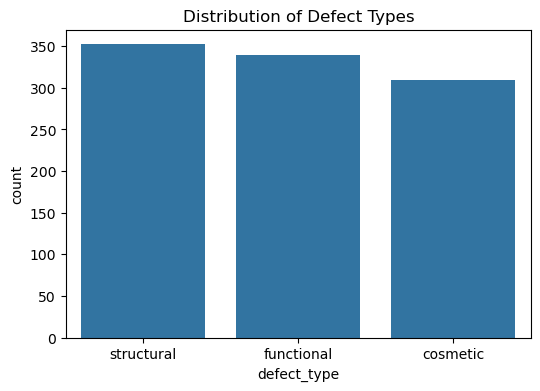

Insight: Structural defects are the most common, followed by functional and cosmetic. This suggests that product durability issues dominate overall defect counts.


In [40]:
plt.figure(figsize=(6,4))
sns.countplot(x="defect_type", data=df, order=df['defect_type'].value_counts().index)
plt.title("Distribution of Defect Types")
plt.show()

print("Insight: Structural defects are the most common, followed by functional and cosmetic. This suggests that product durability issues dominate overall defect counts.")


#### Severity distribution 

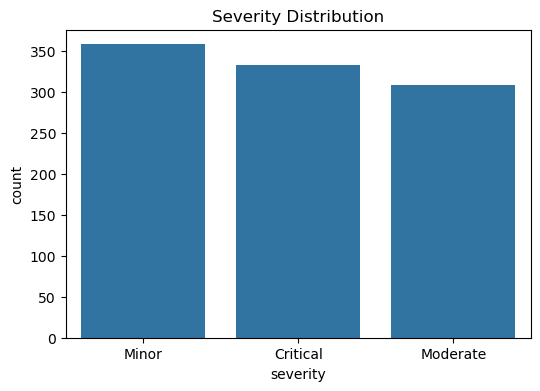

Insight: Minor defects make up the majority, but critical defects still represent a significant proportion. This indicates that while many issues are low impact, high-severity cases cannot be ignored.


In [41]:
plt.figure(figsize=(6,4))
sns.countplot(x="severity", data=df, order=df['severity'].value_counts().index)
plt.title("Severity Distribution")
plt.show()

print("Insight: Minor defects make up the majority, but critical defects still represent a significant proportion. This indicates that while many issues are low impact, high-severity cases cannot be ignored.")


#### Defect counts per Product

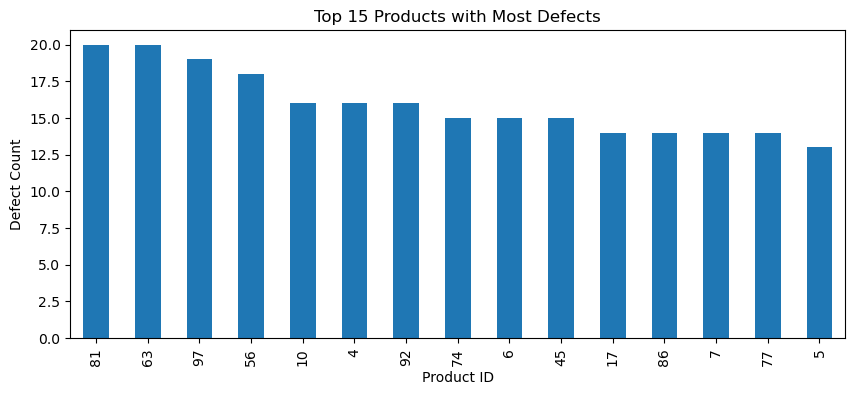

Insight: A small set of products account for most defects. Targeting these product  for quality improvement could yield the biggest gains.


In [42]:
plt.figure(figsize=(10,4))
df['product_id'].value_counts().head(15).plot(kind="bar")
plt.title("Top 15 Products with Most Defects")
plt.xlabel("Product ID")
plt.ylabel("Defect Count")
plt.show()

print("Insight: A small set of products account for most defects. Targeting these product  for quality improvement could yield the biggest gains.")


#### Defect counts per day_of_week

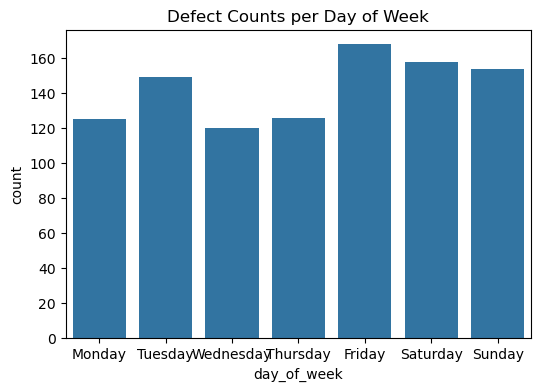

Insight: Defects peak on Friday, with high counts also observed on Saturday and Sunday. This suggests end-of-week and weekend shifts may face more quality challenges, possibly due to workload or process variations.


In [43]:
plt.figure(figsize=(6,4))
sns.countplot(x="day_of_week", data=df, order=["Monday","Tuesday","Wednesday","Thursday","Friday","Saturday","Sunday"])
plt.title("Defect Counts per Day of Week")
plt.show()
print("Insight: Defects peak on Friday, with high counts also observed on Saturday and Sunday. This suggests end-of-week and weekend shifts may face more quality challenges, possibly due to workload or process variations.")

## Pareto Analysis: (80/20) Rule

#### Top 20% defect types causing 80% problems 

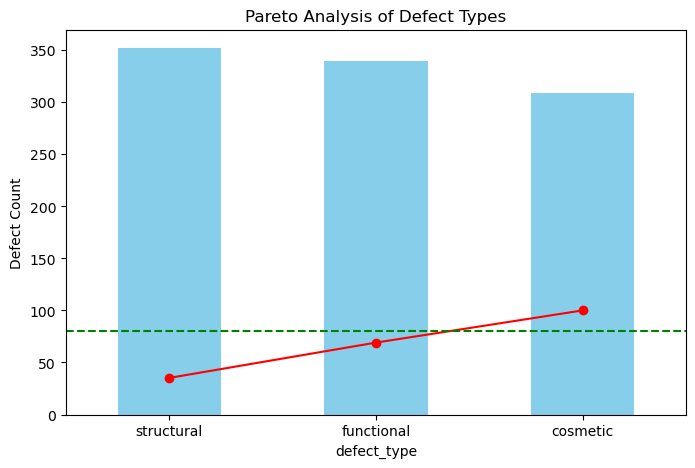

Insight: Structural defects are the single largest contributor, and together with functional defects they account for ~80% of all issues. Cosmetic defects make up the remaining share. Prioritizing structural and functional defect reduction will yield the biggest impact.


In [44]:
defect_counts = df['defect_type'].value_counts()
cum_percentage = defect_counts.cumsum() / defect_counts.sum() * 100

plt.figure(figsize=(8,5))
defect_counts.plot(kind="bar", color="skyblue")
plt.ylabel("Defect Count")
plt.title("Pareto Analysis of Defect Types")

# Overlay cumulative percentage line
cum_percentage.plot(marker="o", color="red")
plt.axhline(80, color="green", linestyle="--")
plt.show()

print("Insight: Structural defects are the single largest contributor, and together with functional defects they account for ~80% of all issues. Cosmetic defects make up the remaining share. Prioritizing structural and functional defect reduction will yield the biggest impact.")

## Time Trends:

#### Monthly defect trend

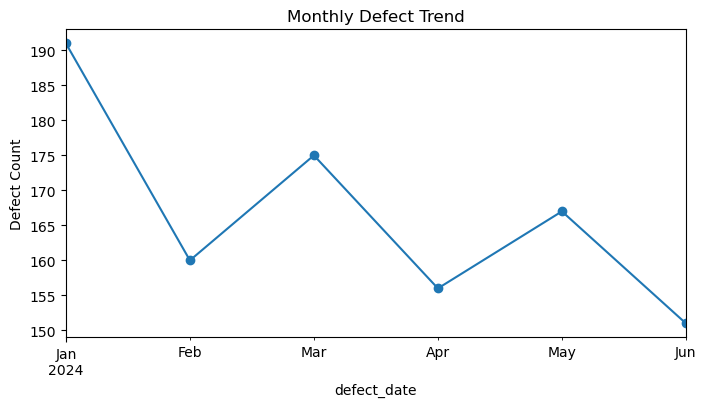

Insight: Defect counts fluctuate month to month. January shows the highest defect count, followed by smaller peaks in March and May. Overall, there is no steady upward trend — instead, defects vary across months.


In [45]:
df['defect_date'] = pd.to_datetime(df['defect_date'], format="%d-%m-%Y", errors="coerce")

# Now you can safely use .dt
monthly_trend = df.groupby(df['defect_date'].dt.to_period("M")).size()

# Plot
monthly_trend.plot(kind="line", marker="o", figsize=(8,4))
plt.title("Monthly Defect Trend")
plt.ylabel("Defect Count")
plt.show()

print("Insight: Defect counts fluctuate month to month. January shows the highest defect count, followed by smaller peaks in March and May. Overall, there is no steady upward trend — instead, defects vary across months.")

#### Weekly pattern 

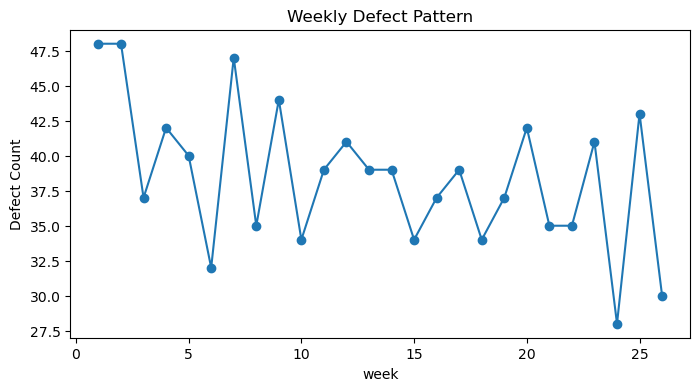

Insight: Certain weeks (e.g., 17–20) show spikes in defects. These may align with production cycles or specific campaigns.


In [46]:
weekly_trend = df.groupby(df['week']).size()
weekly_trend.plot(kind="line", marker="o", figsize=(8,4))
plt.title("Weekly Defect Pattern")
plt.ylabel("Defect Count")
plt.show()

print("Insight: Certain weeks (e.g., 17–20) show spikes in defects. These may align with production cycles or specific campaigns.")


#### Seasonal pattern (quarterly)

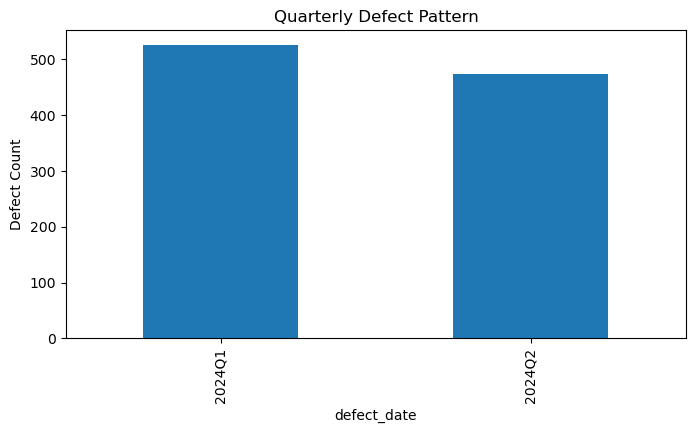

Insight: Q1 shows the highest defect concentration, indicating early-year quality challenges or production ramp-up effects. Defects decreased in Q2, suggesting some improvement or seasonal variation.


In [47]:
quarterly_trend = df.groupby(df['defect_date'].dt.to_period("Q")).size()
quarterly_trend.plot(kind="bar", figsize=(8,4))
plt.title("Quarterly Defect Pattern")
plt.ylabel("Defect Count")
plt.show()

print("Insight: Q1 shows the highest defect concentration, indicating early-year quality challenges or production ramp-up effects. Defects decreased in Q2, suggesting some improvement or seasonal variation.")
